# 01 - The four bridge states

## Purpose

This notebook is the second in a series working toward an accurate,
mathematically proven servo control loop, built on empirical data. Notebook
00 characterized the measurement chain. This notebook establishes what the
H-bridge does to the measured channels in each of its four output states,
so that later notebooks can gate every sample on the state the bridge was
in when the sample was taken.

This notebook has three jobs:

1. Establish, from data, what each bridge state does to the terminal
   voltages, the shunt current and the motion (section 5).
2. Produce the per-state sample-validity map that the later notebooks gate
   on (section 5.4).
3. Measure the coast and brake spin-down behavior (section 6).

The dataset is one test series on a 2-cell lithium battery, each recording
made of three sweeps captured back to back.


## 1. Test setup

The device under test is an SG90-class hobby servo with its stock
electronics replaced by a custom controller board. The signal chain is the
one described in notebook 00, summarized here with the additions this
notebook needs.

- A brushed DC motor driven by an H-bridge with 20 kHz PWM, center
  aligned. The bridge has four output states. **Forward drive** and
  **reverse drive** connect the supply across the motor in either
  polarity. **Brake** pulls both outputs low, so the winding is shorted
  through the two low-side switches. **Coast** turns every switch off, so
  both terminals float.
- **Duty** is the fraction of each PWM period in the drive state. The
  **decay mode** selects what the bridge does for the rest of the period.
  Under **slow decay** the OFF portion is brake. Under **fast decay** the
  OFF portion is coast.
- A gear train couples the motor to the output shaft. A potentiometer on
  the output shaft is read by the MCU's 12-bit ADC. Position stays in
  wiper volts here (angle calibration is a later notebook).
- A 33 mOhm shunt resistor in the motor return path, amplified with gain
  15.0, gives the motor current channel. The recorded value is the
  amplifier output at the ADC pin, offset included. Current crosses the
  shunt only while the bridge drives. In brake the current recirculates
  through the low-side switches. In coast it returns through the switch
  body diodes, crossing the shunt in the negative direction until it dies.
- Both motor terminals are read through 20 kOhm / 10 kOhm resistor
  dividers, channels `vmotor_a` and `vmotor_b`. The bottom leg of each
  divider returns to a bias node of about 0.62 V instead of ground,
  so a terminal as low as -1.2 V keeps its ADC pin above ground and stays
  readable (section 2 gives the tap formula). Each divider loads its
  terminal with 30 kOhm to the bias node.
- The ADC runs two five-channel scans per 50 us period, one triggered at
  the crest of the PWM counter and one at the trough. Under slow decay the
  drive window is centered on the crest. Under fast decay it is centered
  on the trough. Section 5.1 works out which scan sees which state.
- The controller streams one frame per period, with the crest scan's
  shunt, both terminals and position, plus the trough scan's shunt. Every
  frame carries a CRC. Corrupted frames are dropped and counted, so
  corruption turns into missing samples (verified in section 4).

Power is a 2-cell lithium battery, nominal 7.4 V, measured at the driven
terminal in section 5.2. The five recordings were taken in one session
without recharging, so the rail sags slowly from recording to recording.


## 2. Constants and unit conversions

All conversions from ADC counts to physical units use the constants below,
the same as notebook 00.

| Quantity | Value |
|---|---|
| ADC resolution | 12 bit (0..4095 counts) |
| ADC reference | VDD, nominal 3.300 V |
| Motor terminal divider | 20 kOhm top / 10 kOhm bottom, bottom leg returned to the terminal bias |
| Terminal bias $V_B$, nominal | 430 Ohm / 100 Ohm from VDD, 0.623 V |
| Terminal bias $V_B$, measured | per recording, from the segment-0 baseline (section 3) |
| Current shunt | 33 mOhm |
| Current amplifier gain | 15.0 |
| Control period | 50 us (20 kHz) |
| PWM counter | 1200 timer ticks per half period, center aligned |
| Duty encoding | signed, 32767 = 100% |
| Current sampling floor | 160 timer ticks = 13.3% duty |
| Voltage sampling floor | 210 timer ticks = 17.5% duty |

A duty $d$ places the drive window with half-width $1200 d$ ticks around
its center and the OFF window with half-width $1200 (1 - d)$ ticks around
the opposite extreme of the counter. The sampling floors state how far
inside a window the scan must sit for the sample to be settled. They apply
to both windows. A drive-window sample is settled for $d \geq 13.3\%$
(current) and $d \geq 17.5\%$ (voltage). An OFF-window sample is settled
for $d \leq 86.7\%$ (current) and $d \leq 82.5\%$ (voltage). The streamed
`window_valid` flag encodes the current floor of the drive window.

With the divider's bottom leg returned to the bias $V_B$, a terminal
voltage $V_t$ reaches the ADC pin as

$$\text{tap} = \frac{V_t}{3} + \frac{2}{3} V_B, \qquad V_t = 3\,\text{tap} - 2 V_B .$$

With the bridge off and no current, both taps read $V_B$ exactly, which
is how the bias is measured per recording (section 3). Every absolute
terminal voltage below uses the second form with the measured $V_B$ of
its recording. The difference of the two terminals is bias-free, since
both dividers share the one bias node, so that $v_A - v_B = 3\,(\text{tap}_A -
\text{tap}_B)$ in ADC volts.

Two caveats carry over from notebook 00. The ADC reference is the design
value, so every voltage scales with the true VDD of this unit. The
divider, shunt and gain are design values with unmeasured tolerances.

The derived conversion factors:


In [1]:
from pathlib import Path

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import savgol_filter
from scipy.optimize import least_squares

# --- documented constants (see the table above) ---
VDD_V = 3.300               # ADC reference, nominal, not measured
ADC_COUNTS = 4096           # 12-bit converter
DIV_TOP_OHM = 20_000        # motor terminal divider, top leg
DIV_BOT_OHM = 10_000        # motor terminal divider, bottom leg
BIAS_TOP_OHM = 430          # terminal bias divider from VDD, top leg
BIAS_BOT_OHM = 100          # terminal bias divider, bottom leg
SHUNT_OHM = 0.033           # current shunt
AMP_GAIN = 15.0             # current amplifier gain
TICK_HZ = 20_000            # control / sample rate
PWM_HALF_TICKS = 1200       # timer ticks per PWM half period
Q15 = 32767                 # duty full scale as encoded on the wire
FLOOR_I_TICKS = 160         # current sampling floor
FLOOR_V_TICKS = 210         # voltage sampling floor

# --- derived conversion factors ---
V_ADC_PER_COUNT = VDD_V / ADC_COUNTS                       # volts at the ADC pin
V_TERM_PER_COUNT = V_ADC_PER_COUNT * (DIV_TOP_OHM + DIV_BOT_OHM) / DIV_BOT_OHM
DIV_RATIO = (DIV_TOP_OHM + DIV_BOT_OHM) / DIV_BOT_OHM      # 3: tap = Vt/3 + 2/3 VB
VB_NOM_V = VDD_V * BIAS_BOT_OHM / (BIAS_TOP_OHM + BIAS_BOT_OHM)
A_PER_COUNT = V_ADC_PER_COUNT / (AMP_GAIN * SHUNT_OHM)     # amps through the shunt
FLOOR_I_PCT = FLOOR_I_TICKS * 100.0 / PWM_HALF_TICKS
FLOOR_V_PCT = FLOOR_V_TICKS * 100.0 / PWM_HALF_TICKS

def term_V(tap_counts, vb_counts):
    # Absolute terminal voltage from a tap reading: Vt = 3 tap - 2 VB.
    return (DIV_RATIO * tap_counts - (DIV_RATIO - 1) * vb_counts) * V_ADC_PER_COUNT

pd.DataFrame([
    {"quantity": "pot wiper", "value": V_ADC_PER_COUNT * 1e3, "unit": "mV per count"},
    {"quantity": "motor terminal difference", "value": V_TERM_PER_COUNT * 1e3, "unit": "mV per count"},
    {"quantity": "terminal bias, nominal", "value": VB_NOM_V * 1e3, "unit": "mV"},
    {"quantity": "terminal bias, nominal", "value": VB_NOM_V / V_ADC_PER_COUNT, "unit": "counts"},
    {"quantity": "motor current", "value": A_PER_COUNT * 1e3, "unit": "mA per count"},
    {"quantity": "drive window settled, current", "value": FLOOR_I_PCT, "unit": "% duty and above"},
    {"quantity": "drive window settled, voltage", "value": FLOOR_V_PCT, "unit": "% duty and above"},
    {"quantity": "OFF window settled, current", "value": 100 - FLOOR_I_PCT, "unit": "% duty and below"},
    {"quantity": "OFF window settled, voltage", "value": 100 - FLOOR_V_PCT, "unit": "% duty and below"},
]).set_index("quantity").round(4)


,value,unit
quantity,,
pot wiper,0.8057,mV per count
motor terminal difference,2.4170,mV per count
"terminal bias, nominal",622.6415,mV
"terminal bias, nominal",772.8302,counts
motor current,1.6276,mA per count
"drive window settled, current",13.3333,% duty and above
"drive window settled, voltage",17.5000,% duty and above
"OFF window settled, current",86.6667,% duty and below
"OFF window settled, voltage",82.5000,% duty and below


## 3. Capture method

The recordings live in the repository under `notebooks/telemetry/sg90/bridge/`,
one folder per recording. Each recording holds three sweeps, captured back
to back with the same servo state:

- **Slow-decay sweep.** Segment 0 is a one-second baseline with the bridge
  disabled. Segments 1 to 40 are 80 ms drive steps at constant duty, 5% to
  100% in 5% increments, first forward then reverse, under slow decay.
- **Fast-decay sweep.** The same grid under fast decay.
- **Spin-down sweep.** Slow decay. Segment 0 is the baseline. Then, for
  20%, 30% and 40% duty in turn, an 80 ms drive step followed by 400 ms of
  coast, and a second drive step at the same duty followed by 400 ms of
  brake. The pattern runs forward first, then reverse, 24 segments in all.
  The zero-duty segments start when the drive command ends, so the motor
  enters them at whatever speed the drive step reached.

Before every drive step the servo is repositioned at 15% duty toward the
far end of travel, so the step has room to accelerate. The mechanism can
still be moving from that repositioning move when the step begins, in the
direction opposite to the step. Speed at the end of a drive step therefore
varies from step to step, and the entry speed into every coast and brake
segment is measured from the data (section 6).

**Data acceptance.** A recording is accepted only if the host counted zero
dropped frames in all three sweeps. Section 4 re-verifies this from the
data itself.

Each row of a sweep is one 50 us sample: segment number, commanded duty,
direction, tick counter, the firmware's validity flag, position, the
crest-scan shunt (`current_raw`), the trough-scan shunt
(`current_trough`), and the crest-scan terminals (`vmotor_a`,
`vmotor_b`). The spin-down sweep's metadata lists the schedule, from which
the kind of every zero-duty segment (coast or brake) follows.

The segment-0 baseline of every sweep gives two per-recording constants,
the shunt amplifier's bias (mean of `current_raw`) and the terminal bias
$V_B$ (median of `vmotor_a`, cross-checked against `vmotor_b`). The
table lists $V_B$ per recording, with the spread of the six baseline
readings (two terminals, three sweeps).


In [2]:
TELEMETRY = Path("telemetry/sg90/bridge")
SWEEPS = ("slow", "fast", "spindown")

def load_sweep(rec_dir, name):
    df = pd.read_csv(rec_dir / f"{name}.csv.gz")
    meta = json.loads((rec_dir / f"{name}.meta.json").read_text())
    df["duty_pct"] = df["cmd_duty_q15"] * 100.0 / Q15
    df["mag_pct"] = df["duty_pct"].abs().round().astype(int)
    df["bias"] = df.loc[df["seg"] == 0, "current_raw"].mean()
    base = df[df["seg"] == 0]
    df["vb"] = base["vmotor_a"].median()
    df["vb_b"] = base["vmotor_b"].median()
    if name == "spindown":
        # Segment k (k >= 1) is schedule entry (k - 1) mod len(schedule).
        sched = meta["schedule"]
        kinds = ["baseline"] + [
            "drive" if ":" not in s else s.split(":")[0]
            for s in sched * (df["seg"].max() // len(sched))
        ]
        df["kind"] = df["seg"].map(dict(enumerate(kinds)))
    return df, meta

recs = {}
for d in sorted(TELEMETRY.glob("capture-*"), key=lambda p: int(p.name.split("-")[1])):
    recs[d.name] = {name: load_sweep(d, name) for name in SWEEPS}

rows = []
for name, sweeps in recs.items():
    taps = [sweeps[s][0][k].iloc[0] for s in SWEEPS for k in ("vb", "vb_b")]
    vb = sweeps["slow"][0]["vb"].iloc[0]
    rows.append({
        "recording": name,
        "VB [counts]": vb,
        "VB [V]": vb * V_ADC_PER_COUNT,
        "baseline spread [counts]": max(taps) - min(taps),
        "VB minus nominal [mV]": (vb * V_ADC_PER_COUNT - VB_NOM_V) * 1e3,
    })
pd.DataFrame(rows).set_index("recording").round(4)


,VB [counts],VB [V],baseline spread [counts],VB minus nominal [mV]
recording,,,,
capture-1,777.0,0.6260,2.0,3.3595
capture-2,776.0,0.6252,2.0,2.5538
capture-3,776.0,0.6252,2.0,2.5538
capture-4,776.0,0.6252,2.0,2.5538
capture-5,776.0,0.6252,2.0,2.5538


## 4. Data integrity

The transport turns a corrupted frame into a missing sample. The table
recomputes the missing-sample count of every sweep in every recording from
the tick column, which increments by one per sample within a segment.


In [3]:
rows = []
for name, sweeps in recs.items():
    for sweep, (df, meta) in sweeps.items():
        missing = 0
        for _, seg in df.groupby("seg"):
            ticks = seg["tick"].to_numpy()
            missing += int(ticks[-1] - ticks[0] + 1 - len(ticks))
        rows.append({
            "recording": name,
            "sweep": sweep,
            "samples": len(df),
            "segments": df["seg"].nunique(),
            "missing_samples": missing,
        })
pd.DataFrame(rows).set_index(["recording", "sweep"])


samples  segments  missing_samples
recording sweep                                       
capture-1 slow        84000        41                0
          fast        84000        41                0
          spindown   135200        25                0
capture-2 slow        84000        41                0
          fast        84000        41                0
          spindown   135200        25                0
capture-3 slow        84000        41                0
          fast        84000        41                0
          spindown   135200        25                0
capture-4 slow        84000        41                0
          fast        84000        41                0
          spindown   135200        25                0
capture-5 slow        84000        41                0
          fast        84000        41                0
          spindown   135200        25                0

Every sweep of every recording has zero missing samples.

## 5. The four states

### 5.1 Which scan sees which state

The two scans per period sit at the two extremes of the center-aligned
PWM counter. The drive window is centered on the crest under slow decay
and on the trough under fast decay, so each scan sees a different bridge
state depending on the decay mode:

| Decay | Crest scan (`current_raw`, `vmotor_a`, `vmotor_b`) | Trough scan (`current_trough`) |
|---|---|---|
| Slow | drive | brake |
| Fast | coast | drive |

Only the shunt is streamed from the trough scan, so the terminal voltages
of the brake state come from the spin-down sweep's brake segments (a brake
state lasting the whole period, seen by the crest scan) and the terminal
voltages of the coast state come from the fast-decay sweep's crest scan
and the spin-down sweep's coast segments. The rest of section 5 checks
each cell of this table against the data.

### 5.2 Slow decay

Under slow decay the crest scan reads the drive state. The figure shows
the crest-scan shunt current (bias subtracted, converted to amperes) and
the two terminals against duty, per recording, for both directions. The
trough scan reads the brake state, and its shunt reading is plotted as an
offset from the baseline bias.

Per drive step the terminal levels are the median of the step, and the
current is the median of the step's flagged-valid samples.


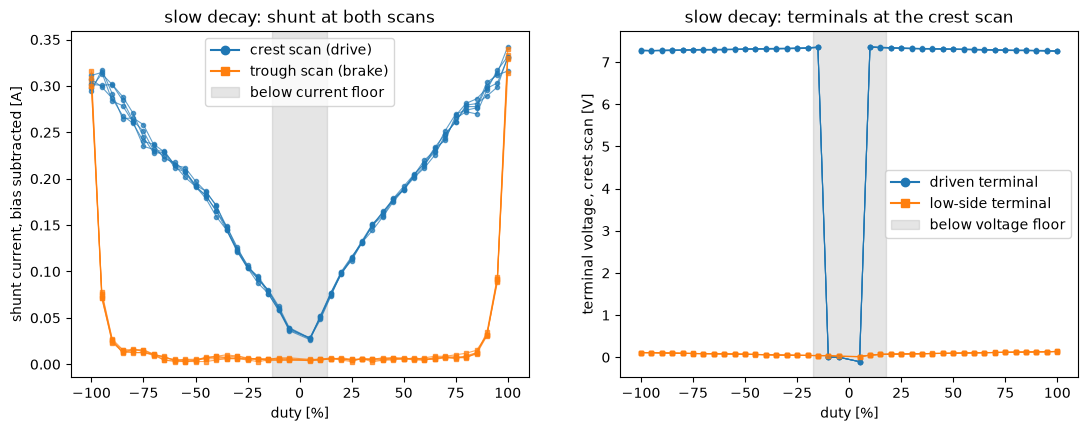

,valid_frac,crest_current_A,trough_offset_counts,driven_terminal_V,lowside_terminal_V
mag_pct,,,,,
5,0.000,0.033,3.032,-0.051,0.019
10,0.000,0.055,3.232,3.680,0.045
15,0.999,0.077,3.432,7.348,0.054
20,0.999,0.095,3.332,7.334,0.058
30,0.999,0.128,4.032,7.321,0.066
50,0.999,0.191,3.132,7.305,0.084
70,0.999,0.240,5.532,7.289,0.100
80,0.999,0.270,7.132,7.279,0.107
85,0.999,0.278,8.132,7.277,0.111


In [4]:
def slow_steps(df):
    out = []
    for seg_id, seg in df[df["seg"] > 0].groupby("seg"):
        d = seg["duty_pct"].iloc[0]
        hi, lo = ("vmotor_a", "vmotor_b") if d > 0 else ("vmotor_b", "vmotor_a")
        vb = seg["vb"].iloc[0]
        out.append({
            "duty_pct": d,
            "mag_pct": int(round(abs(d))),
            "valid_frac": seg["window_valid"].mean(),
            "crest_current_A": (seg["current_raw"].median() - seg["bias"].iloc[0]) * A_PER_COUNT,
            "trough_offset_counts": seg["current_trough"].median() - seg["bias"].iloc[0],
            "driven_terminal_V": term_V(seg[hi].median(), vb),
            "lowside_terminal_V": term_V(seg[lo].median(), vb),
        })
    return pd.DataFrame(out).sort_values("duty_pct")

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
for name, sweeps in recs.items():
    st = slow_steps(sweeps["slow"][0])
    axes[0].plot(st["duty_pct"], st["crest_current_A"], "-o", ms=3, lw=0.8,
                 color="tab:blue", alpha=0.7)
    axes[0].plot(st["duty_pct"], st["trough_offset_counts"] * A_PER_COUNT, "-s", ms=3,
                 lw=0.8, color="tab:orange", alpha=0.7)
    axes[1].plot(st["duty_pct"], st["driven_terminal_V"], "-o", ms=3, lw=0.8,
                 color="tab:blue", alpha=0.7)
    axes[1].plot(st["duty_pct"], st["lowside_terminal_V"], "-s", ms=3, lw=0.8,
                 color="tab:orange", alpha=0.7)
axes[0].plot([], [], "-o", color="tab:blue", label="crest scan (drive)")
axes[0].plot([], [], "-s", color="tab:orange", label="trough scan (brake)")
axes[0].axvspan(-FLOOR_I_PCT, FLOOR_I_PCT, color="grey", alpha=0.2, label="below current floor")
axes[0].set_xlabel("duty [%]")
axes[0].set_ylabel("shunt current, bias subtracted [A]")
axes[0].set_title("slow decay: shunt at both scans")
axes[0].legend()
axes[1].plot([], [], "-o", color="tab:blue", label="driven terminal")
axes[1].plot([], [], "-s", color="tab:orange", label="low-side terminal")
axes[1].axvspan(-FLOOR_V_PCT, FLOOR_V_PCT, color="grey", alpha=0.2, label="below voltage floor")
axes[1].set_xlabel("duty [%]")
axes[1].set_ylabel("terminal voltage, crest scan [V]")
axes[1].set_title("slow decay: terminals at the crest scan")
axes[1].legend()
plt.show()

# Pooled over recordings and directions, by duty magnitude.
allst = pd.concat([slow_steps(s["slow"][0]) for s in recs.values()])
(allst.groupby("mag_pct")[["valid_frac", "crest_current_A", "trough_offset_counts",
                            "driven_terminal_V", "lowside_terminal_V"]]
      .mean().round(3).iloc[[0, 1, 2, 3, 5, 9, 13, 15, 16, 17, 18, 19]])


Findings for the drive state (crest scan):

- The shunt current rises with duty from the first step. The validity flag
  sets from the 15% step in every recording, the first grid point above
  the 13.3% floor. The current curve passes through the flag edge without
  a kink.
- The driven terminal reads the supply rail, about 7.3 V, from the 10%
  step forward and the 15% step in reverse. The reverse edge is one grid
  step later because terminal B is the later of the two terminal slots in
  the scan. The 17.5% voltage floor covers both edges. The rail sags by
  about 0.08 V from 15% to 100% duty within a sweep, and by 0.01 V from
  the first recording to the last (table in section 5.4).
- The low-side terminal rises from 0.02 V to 0.12 V with current. Its slope
  against the shunt current is 0.30 Ohm, the on-resistance of the
  low-side switch plus the shunt.

Findings for the brake state (trough scan):

- The trough shunt sits within 20 counts (0.03 A equivalent) of the
  baseline bias up to the 85% step in every recording and the 90% step in
  four of five, with a small offset that grows with duty (about 3 counts
  at low duty, 8 counts at 85%, 18 at 90%). *Hypothesis (not tested here):
  the offset is the amplifier still recovering from the drive pulse.*
- At 95% the trough reading climbs toward the drive current, and at 100%
  the two scans read the same value, because there is no OFF window
  left. This matches the 86.7% OFF-window floor from section 2.

The brake state's terminal voltages come from the spin-down sweep in
section 6. Both terminals sit within 0.04 V of ground for the whole
brake segment, which puts their taps at two thirds of the bias (table in
section 5.4).

### 5.3 Fast decay

Under fast decay the trough scan reads the drive state and the crest scan
reads the coast state. The left panel shows the shunt at both scans. The
right panel shows the sum of the two crest-scan terminals, $v_A + v_B$,
which serves as the phase discriminator of the coast window. At rest both
terminals read the bias, so the sum's baseline is $2 V_B$, about 1.25 V.
A floating terminal cannot exceed the rail. A terminal reading above it
is being held there by a conducting high-side body diode, which means
winding current is still flowing, and the sum then exceeds the rail as
well, since the other terminal cannot fall below its clamp. The measured
rail (section 5.2) is drawn as the discriminator threshold. The table
also lists the terminal driven high and the terminal driven low
separately.


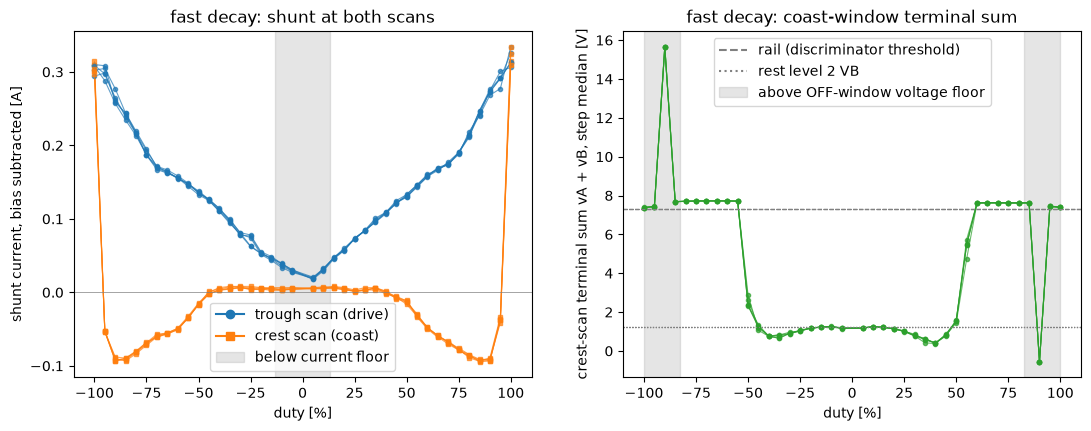

,valid_frac,trough_current_A,crest_current_A,high_terminal_V,low_terminal_V,sum_median_V,diode_frac,travel_mV
mag_pct,,,,,,,,
5,0.000,0.024,0.005,0.484,0.690,1.174,0.000,-60.304
10,0.000,0.034,0.005,0.595,0.655,1.251,0.000,0.403
15,0.999,0.046,0.006,0.545,0.674,1.219,0.000,-0.121
20,0.999,0.056,0.005,0.467,0.693,1.159,0.000,-0.121
25,0.999,0.072,0.004,0.317,0.709,1.026,0.000,-0.282
30,0.999,0.082,0.005,0.137,0.719,0.857,0.000,2.780
35,0.999,0.097,0.006,-0.081,0.736,0.655,0.000,30.132
40,0.999,0.110,0.002,-0.346,0.882,0.578,0.000,45.762
45,0.999,0.124,-0.004,-0.442,1.456,1.015,0.007,52.167


In [5]:
def rail_V(sweeps):
    # Supply rail per recording: median driven terminal over the valid
    # slow-decay drive steps at 20% and above.
    df = sweeps["slow"][0]
    v = df[(df["seg"] > 0) & (df["window_valid"] == 1) & (df["mag_pct"] >= 20)]
    driven = np.where(v["duty_pct"] > 0, v["vmotor_a"], v["vmotor_b"])
    return term_V(np.median(driven), df["vb"].iloc[0])

def fast_steps(df, rail):
    out = []
    for seg_id, seg in df[df["seg"] > 0].groupby("seg"):
        d = seg["duty_pct"].iloc[0]
        hi, lo = ("vmotor_a", "vmotor_b") if d > 0 else ("vmotor_b", "vmotor_a")
        vb = seg["vb"].iloc[0]
        vA, vB = term_V(seg["vmotor_a"], vb), term_V(seg["vmotor_b"], vb)
        ssum = vA + vB
        p = seg["pos"].to_numpy() * V_ADC_PER_COUNT
        out.append({
            "duty_pct": d,
            "mag_pct": int(round(abs(d))),
            "valid_frac": seg["window_valid"].mean(),
            "trough_current_A": (seg["current_trough"].median() - seg["bias"].iloc[0]) * A_PER_COUNT,
            "crest_current_A": (seg["current_raw"].median() - seg["bias"].iloc[0]) * A_PER_COUNT,
            "high_terminal_V": term_V(seg[hi].median(), vb),
            "low_terminal_V": term_V(seg[lo].median(), vb),
            "sum_median_V": ssum.median(),
            "diode_frac": (ssum > rail).mean(),
            "travel_mV": (np.median(p[-20:]) - np.median(p[:20])) * 1e3 * np.sign(d),
        })
    return pd.DataFrame(out).sort_values("duty_pct")

rails = {name: rail_V(sweeps) for name, sweeps in recs.items()}
vbs = {name: sweeps["slow"][0]["vb"].iloc[0] * V_ADC_PER_COUNT for name, sweeps in recs.items()}

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
for name, sweeps in recs.items():
    st = fast_steps(sweeps["fast"][0], rails[name])
    axes[0].plot(st["duty_pct"], st["trough_current_A"], "-o", ms=3, lw=0.8,
                 color="tab:blue", alpha=0.7)
    axes[0].plot(st["duty_pct"], st["crest_current_A"], "-s", ms=3, lw=0.8,
                 color="tab:orange", alpha=0.7)
    axes[1].plot(st["duty_pct"], st["sum_median_V"], "-o", ms=3, lw=0.8,
                 color="tab:green", alpha=0.7)
    axes[1].axhline(rails[name], color="grey", lw=0.8, ls="--")
    axes[1].axhline(2 * vbs[name], color="grey", lw=0.8, ls=":")
axes[0].plot([], [], "-o", color="tab:blue", label="trough scan (drive)")
axes[0].plot([], [], "-s", color="tab:orange", label="crest scan (coast)")
axes[0].axhline(0, color="grey", lw=0.5)
axes[0].axvspan(-FLOOR_I_PCT, FLOOR_I_PCT, color="grey", alpha=0.2, label="below current floor")
axes[0].set_xlabel("duty [%]")
axes[0].set_ylabel("shunt current, bias subtracted [A]")
axes[0].set_title("fast decay: shunt at both scans")
axes[0].legend()
axes[1].plot([], [], "--", color="grey", label="rail (discriminator threshold)")
axes[1].plot([], [], ":", color="grey", label="rest level 2 VB")
axes[1].axvspan(-100, -(100 - FLOOR_V_PCT), color="grey", alpha=0.2)
axes[1].axvspan(100 - FLOOR_V_PCT, 100, color="grey", alpha=0.2,
                label="above OFF-window voltage floor")
axes[1].set_xlabel("duty [%]")
axes[1].set_ylabel("crest-scan terminal sum vA + vB, step median [V]")
axes[1].set_title("fast decay: coast-window terminal sum")
axes[1].legend(loc="upper center")
plt.show()

allft = pd.concat([fast_steps(s["fast"][0], rails[n]) for n, s in recs.items()])
(allft.groupby("mag_pct")[["valid_frac", "trough_current_A", "crest_current_A",
                            "high_terminal_V", "low_terminal_V", "sum_median_V",
                            "diode_frac", "travel_mV"]]
      .mean().round(3))


Findings for the drive state (trough scan):

- The trough shunt reads the drive current, rising monotonically from 5%
  to 100%, and the validity flag sets from the 15% step as under slow
  decay. The same floor applies to both decay modes.

Findings for the coast state (crest scan), by duty range:

- **5% to 30%.** The crest shunt reads the bias within 5 counts. Both
  terminals sit near the bias. The terminal driven low reads 0.66 to
  0.72 V, a little above it, and the terminal driven high drifts below it
  as duty grows, from 0.48 V at 5% to 0.14 V at 30%. The position column
  shows no net motion up to 25%. *Hypothesis (not tested here): the drive
  pulse is too short for the current to build against the winding
  inductance, so conduction is discontinuous and the average torque falls
  below the friction threshold.*
- **60% to 85%.** The terminal driven low sits at 8.23 V, one diode drop
  (0.93 V) above the rail, in most samples of each step, and the terminal
  driven high at -0.58 V, one body-diode drop below ground. The 55% step
  is mixed. This is the diode phase. Winding current is still flowing
  when the scan fires, returning through the high-side body diode of the
  terminal that was driven low and the low-side body diode of the
  terminal that was driven high, and both drops are now readable. The
  crest shunt reads below the bias in the same range, the freewheel
  current crossing the shunt backward, growing from 0.05 A at 60% to
  0.09 A at 85%.
- **35% to 50%.** The terminal driven high reaches the clamp level,
  -0.35 V at 40% and -0.44 V at 45%, while the terminal driven low rises
  steeply from 0.74 V to 2.5 V. Almost no sample is above the rail up to
  45%, and one fifth of the 50% step is. The next code cell examines what
  this reading is.
- **90% and 95%.** The OFF window is narrower than the terminal slots'
  offset from the crest, so the terminal samples land partly inside the
  drive window and mix the two states. In the reverse 90% step one
  terminal reads the diode level and the other the drive level, which
  puts the sum far above the rail. This is the 82.5% OFF-window voltage
  floor from section 2. At 100% both scans read the drive state.

The terminal reading in the 35% to 50% range needs a closer look. If it
were the back-EMF of a spinning motor, it would grow with speed within a
step as the motor accelerates, and it would put the terminal driven high
above the terminal driven low, the polarity the coast segments of section
6.1 show. The figure follows one step at 45% duty through its 80 ms.


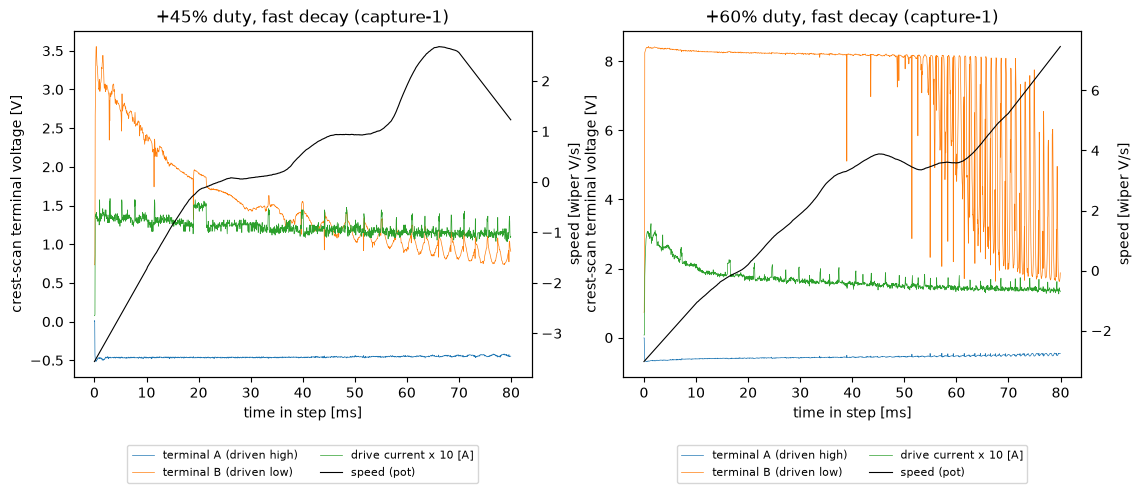

,speed_Vps,terminal_B_V,terminal_A_V,drive_current_A
quarter,,,,
1,-1.525,2.302,-0.467,0.132
2,0.191,1.452,-0.463,0.124
3,1.180,1.113,-0.456,0.119
4,1.967,0.863,-0.443,0.116


In [6]:
name, sweeps = next(iter(recs.items()))
df = sweeps["fast"][0]
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
for ax, pct in zip(axes, [45, 60]):
    seg = df[np.isclose(df["duty_pct"], pct, atol=0.5)]
    t = (seg["tick"] - seg["tick"].iloc[0]) / (TICK_HZ / 1000)
    p = seg["pos"].to_numpy() * V_ADC_PER_COUNT
    speed = savgol_filter(p, 401, 2, deriv=1, delta=1 / TICK_HZ)
    vb = seg["vb"].iloc[0]
    ax.plot(t, term_V(seg["vmotor_a"], vb), lw=0.5, label="terminal A (driven high)")
    ax.plot(t, term_V(seg["vmotor_b"], vb), lw=0.5, label="terminal B (driven low)")
    ax.plot(t, (seg["current_trough"] - seg["bias"]) * A_PER_COUNT * 10, lw=0.5,
            label="drive current x 10 [A]")
    ax.set_xlabel("time in step [ms]")
    ax.set_ylabel("crest-scan terminal voltage [V]")
    ax2 = ax.twinx()
    ax2.plot(t, speed, color="k", lw=0.8, label="speed (pot)")
    ax2.set_ylabel("speed [wiper V/s]")
    ax.set_title(f"+{pct}% duty, fast decay ({name})")
    h1, l1 = ax.get_legend_handles_labels()
    h2, l2 = ax2.get_legend_handles_labels()
    ax.legend(h1 + h2, l1 + l2, loc="upper center", bbox_to_anchor=(0.5, -0.18),
              ncol=2, fontsize=8)
plt.show()

# Quarter-by-quarter means of the +45% step, every recording.
rows = []
for name, sweeps in recs.items():
    seg = sweeps["fast"][0]
    seg = seg[np.isclose(seg["duty_pct"], 45, atol=0.5)]
    p = seg["pos"].to_numpy() * V_ADC_PER_COUNT
    speed = savgol_filter(p, 401, 2, deriv=1, delta=1 / TICK_HZ)
    vb = seg["vb"].iloc[0]
    n = len(seg) // 4
    for q in range(4):
        sl = slice(q * n, (q + 1) * n)
        rows.append({
            "recording": name,
            "quarter": q + 1,
            "speed_Vps": speed[sl].mean(),
            "terminal_B_V": term_V(seg["vmotor_b"].iloc[sl].median(), vb),
            "terminal_A_V": term_V(seg["vmotor_a"].iloc[sl].median(), vb),
            "drive_current_A": (seg["current_trough"].iloc[sl].median()
                                - seg["bias"].iloc[0]) * A_PER_COUNT,
        })
pd.DataFrame(rows).groupby("quarter")[["speed_Vps", "terminal_B_V", "terminal_A_V",
                                        "drive_current_A"]].mean().round(3)


Within the 45% step the reading on terminal B falls from about 2.3 V to
0.9 V while the speed rises from below zero (residual motion from the
repositioning move) to 2.0 wiper V/s, and the drive current falls
slightly as the motor speeds up. Terminal A, the terminal driven high,
sits at the clamp level of -0.45 V throughout. In the coast segments of
section 6.1 the back-EMF puts the terminal driven high above the other
and grows with speed. The fast-decay crest reading has the opposite
polarity and the opposite speed dependence, and it is present at 10% to
25% where the motor does not move at all. It is therefore a residue of
the diode phase and carries no speed information. *Hypothesis (not tested
here): after the diode current dies, the terminal that was held at rail
plus one diode drop discharges toward the bias through its 30 kOhm
divider and the output-node capacitance, and the scan catches it part
way down, while a small remaining current holds the other terminal at
its body-diode clamp. The reading grows with duty because a larger
current lengthens the diode phase and leaves less time for the discharge
before the fixed scan instant.*

The consequence for the series is that the fast-decay crest scan delivers
no direct back-EMF sample at any duty in this scan geometry. Direct
back-EMF is available from the coast segments of the spin-down sweep
(section 6.1), where the scan sits hundreds of microseconds after the
current has died.

### 5.4 Validity map

The map below records, for every bridge state and scan, the duty range in
which each channel reads a settled value of that state. The ranges come
from the data of every recording, on the 5% grid of the sweeps. The
data-derived edges are computed first, then assembled with the configured
floors of section 2.


In [7]:
def edges(name, sweeps):
    rail = rails[name]
    slow = sweeps["slow"][0]
    fast = sweeps["fast"][0]
    st = slow_steps(slow)
    ft = fast_steps(fast, rail)
    fwd, rev = st[st["duty_pct"] > 0], st[st["duty_pct"] < 0]
    e = {"recording": name}
    e["flag_from_pct"] = int(st[st["valid_frac"] > 0.5]["mag_pct"].min())
    e["terminal_A_from_pct"] = int(fwd[fwd["driven_terminal_V"] > rail / 2]["mag_pct"].min())
    e["terminal_B_from_pct"] = int(rev[rev["driven_terminal_V"] > rail / 2]["mag_pct"].min())
    def both_dirs(tab, cond):
        # Grid points where the condition holds in both directions.
        ok = tab[cond].groupby("mag_pct").size() == 2
        return set(ok[ok].index)
    def run_up_from(ok, start):
        # Last grid point of the contiguous run that starts at `start`.
        pct = start
        while pct + 5 in ok:
            pct += 5
        return pct
    ok = both_dirs(st, st["trough_offset_counts"].abs() <= 20)
    e["trough_bias_to_pct"] = run_up_from(ok, 5)
    ok = both_dirs(ft, ft["crest_current_A"].abs() <= 10 * A_PER_COUNT)
    e["fast_crest_bias_to_pct"] = run_up_from(ok, 5)
    ok = both_dirs(ft, ft["diode_frac"] >= 0.5)
    e["diode_phase_from_pct"] = min(ok)
    e["diode_phase_to_pct"] = run_up_from(ok, min(ok))
    e["rail_V"] = rail
    e["VB_V"] = vbs[name]
    ok = st[(st["mag_pct"] >= 20) & (st["mag_pct"] <= 85)]
    e["lowside_R_ohm"] = np.polyfit(ok["crest_current_A"], ok["lowside_terminal_V"], 1)[0]
    dl = ft[(ft["mag_pct"] >= e["diode_phase_from_pct"]) & (ft["mag_pct"] <= e["diode_phase_to_pct"])]
    e["diode_low_terminal_V"] = dl["low_terminal_V"].median()
    e["diode_high_terminal_V"] = dl["high_terminal_V"].median()
    # brake terminals, from the spin-down brake segments
    sp = sweeps["spindown"][0]
    br = sp[sp["kind"] == "brake"]
    vb = sp["vb"].iloc[0]
    e["brake_terminal_max_V"] = max(term_V(br["vmotor_a"].quantile(0.99), vb),
                                    term_V(br["vmotor_b"].quantile(0.99), vb))
    e["brake_shunt_offset_counts"] = br["current_raw"].median() - sp["bias"].iloc[0]
    # coast clamp, from the spin-down coast segments: the negative terminal
    # once the EMF is well above 1 V
    co = sp[sp["kind"] == "coast"]
    d = co["dir"].to_numpy()
    vA, vB = term_V(co["vmotor_a"].to_numpy(), vb), term_V(co["vmotor_b"].to_numpy(), vb)
    emf = (vA - vB) * d
    e["coast_clamp_V"] = np.median(np.where(d > 0, vB, vA)[emf > 1.5])
    return e

edge_tab = pd.DataFrame([edges(n, s) for n, s in recs.items()]).set_index("recording")
edge_tab.round(3)


,flag_from_pct,terminal_A_from_pct,terminal_B_from_pct,trough_bias_to_pct,fast_crest_bias_to_pct,diode_phase_from_pct,diode_phase_to_pct,rail_V,VB_V,lowside_R_ohm,diode_low_terminal_V,diode_high_terminal_V,brake_terminal_max_V,brake_shunt_offset_counts,coast_clamp_V
recording,,,,,,,,,,,,,,,
capture-1,15,10,15,90,45,60,85,7.311,0.626,0.304,8.239,-0.575,0.035,2.779,-0.465
capture-2,15,10,15,90,50,60,85,7.306,0.625,0.299,8.233,-0.575,0.035,3.869,-0.467
capture-3,15,10,15,85,45,60,85,7.303,0.625,0.304,8.231,-0.575,0.035,3.371,-0.465
capture-4,15,10,15,90,45,60,85,7.299,0.625,0.300,8.228,-0.576,0.035,3.456,-0.467
capture-5,15,10,15,90,50,60,85,7.299,0.625,0.301,8.227,-0.577,0.035,2.795,-0.467


In [8]:
# Conservative over recordings: latest lower edge, earliest upper edge.
def as_edges(s):
    return {k: (int(v) if k.endswith("_pct") else v) for k, v in s.items()}
lo = as_edges(edge_tab.max())
hi = as_edges(edge_tab.min())
mid = edge_tab.mean()
rows = [
    ("drive", "slow", "crest", "shunt",
     f">= {FLOOR_I_PCT:.1f}", f"flag from {lo['flag_from_pct']}%",
     "drive current plus bias", "current"),
    ("drive", "slow", "crest", "driven terminal",
     f">= {FLOOR_V_PCT:.1f}", f"A from {lo['terminal_A_from_pct']}%, B from {lo['terminal_B_from_pct']}%",
     "supply rail minus the high-side drop", "supply estimate"),
    ("drive", "slow", "crest", "low-side terminal",
     f">= {FLOOR_V_PCT:.1f}", f"A from {lo['terminal_A_from_pct']}%, B from {lo['terminal_B_from_pct']}%",
     f"current times low-side on-resistance plus shunt, about {mid['lowside_R_ohm']:.2f} Ohm", "switch drop"),
    ("drive", "fast", "trough", "shunt",
     f">= {FLOOR_I_PCT:.1f}", f"flag from {lo['flag_from_pct']}%",
     "drive current plus bias", "current"),
    ("brake", "slow", "trough", "shunt",
     f"<= {100 - FLOOR_I_PCT:.1f}", f"within 20 counts of bias to {hi['trough_bias_to_pct']}%",
     "bias plus a recovery offset growing with duty", "live bias tracker"),
    ("brake", "spin-down segment", "crest", "both terminals",
     "any", f"below {lo['brake_terminal_max_V']:.2f} V in all samples (tap at 2/3 VB)",
     "near ground, winding shorted through the low-side switches", "state check"),
    ("brake", "spin-down segment", "crest", "shunt",
     "any", f"offset {lo['brake_shunt_offset_counts']:.0f} counts",
     "bias, no current through the shunt", "bias"),
    ("coast", "fast", "crest", "shunt",
     f"<= {100 - FLOOR_I_PCT:.1f}", f"within 10 counts of bias to {hi['fast_crest_bias_to_pct']}%",
     "bias where the current has died, negative freewheel current in the diode phase", "bias, diode current"),
    ("coast", "fast", "crest", "terminals, diode phase",
     f"<= {100 - FLOOR_V_PCT:.1f}", f"sum above rail: {lo['diode_phase_from_pct']}% to {hi['diode_phase_to_pct']}%",
     f"rail plus one diode drop ({mid['diode_low_terminal_V'] - mid['rail_V']:.2f} V) on the terminal driven low, "
     f"{mid['diode_high_terminal_V']:.2f} V on the other",
     "phase discriminator only"),
    ("coast", "fast", "crest", "terminals, sum below rail",
     f"<= {100 - FLOOR_V_PCT:.1f}", f"5% to {lo['diode_phase_from_pct'] - 10}%, {lo['diode_phase_from_pct'] - 5}% mixed",
     "diode-phase residue on the terminal driven low, the other clamped, unrelated to speed", "none"),
    ("coast", "spin-down segment", "crest", "vA - vB",
     "any", "from the fourth sample after the drive ends, sum below rail",
     "direct back-EMF, bias-free (section 6.1)", "speed"),
    ("coast", "spin-down segment", "crest", "negative terminal",
     "any", f"{mid['coast_clamp_V']:.2f} V once the EMF exceeds about 1 V",
     "driver body-diode clamp, the positive terminal carries the rest of the EMF", "state check"),
    ("coast", "spin-down segment", "crest", "shunt",
     "any", "from the fourth sample after the drive ends",
     "bias, no current through the shunt", "bias"),
]
validity_map = pd.DataFrame(rows, columns=[
    "state", "decay or segment", "scan", "channel", "configured duty [%]",
    "measured range", "reads", "use in later notebooks"]).set_index(["state", "decay or segment", "scan", "channel"])
pd.set_option("display.max_colwidth", 90)
validity_map


configured duty [%]  \
state decay or segment  scan   channel                                         
drive slow              crest  shunt                                 >= 13.3   
                               driven terminal                       >= 17.5   
                               low-side terminal                     >= 17.5   
      fast              trough shunt                                 >= 13.3   
brake slow              trough shunt                                 <= 86.7   
      spin-down segment crest  both terminals                            any   
                               shunt                                     any   
coast fast              crest  shunt                                 <= 86.7   
                               terminals, diode phase                <= 82.5   
                               terminals, sum below rail             <= 82.5   
      spin-down segment crest  vA - vB                                   any   
                               negative terminal                         any   
                               shunt                                     any   

                                                                                                       measured range  \
state decay or segment  scan   channel                                                                                  
drive slow              crest  shunt                                                                    flag from 15%   
                               driven terminal                                                 A from 10%, B from 15%   
                               low-side terminal                                               A from 10%, B from 15%   
      fast              trough shunt                                                                    flag from 15%   
brake slow              trough shunt                                                  within 20 counts of bias to 85%   
      spin-down segment crest  both terminals                             below 0.04 V in all samples (tap at 2/3 VB)   
                               shunt                                                                  offset 4 counts   
coast fast              crest  shunt                                                  within 10 counts of bias to 45%   
                               terminals, diode phase                                      sum above rail: 60% to 85%   
                               terminals, sum below rail                                         5% to 50%, 55% mixed   
      spin-down segment crest  vA - vB                    from the fourth sample after the drive ends, sum below rail   
                               negative terminal                               -0.47 V once the EMF exceeds about 1 V   
                               shunt                                      from the fourth sample after the drive ends   

                                                                                                                                          reads  \
state decay or segment  scan   channel                                                                                                            
drive slow              crest  shunt                                                                                    drive current plus bias   
                               driven terminal                                                             supply rail minus the high-side drop   
                               low-side terminal                                current times low-side on-resistance plus shunt, about 0.30 Ohm   
      fast              trough shunt                                                                                    drive current plus bias   
brake slow              trough shunt                                                              bias plus a recovery offset growing with duty   
      spin-

The measured edges agree with the configured floors on the 5% grid in
every recording, and the diode-phase range confirms the OFF-window
voltage floor from the coast side. In corrected units, with each terminal
taken as $3\,\text{tap} - 2 V_B$, the sum $v_A + v_B$ rests at $2 V_B$
and exceeds the rail only in the diode phase, which is the discriminator
rule the later notebooks apply.

## 6. Spin-down

The spin-down sweep enters each coast or brake segment at the speed the
preceding 80 ms drive step reached. Entry speeds range from about 2 to
10 wiper V/s and vary from step to step (section 3), so coast and brake
are compared through fitted models against measured speed, never by
pairing segments.

### 6.1 Terminal voltages during coast as direct back-EMF

During a coast segment the bridge is off, so once the winding current has
died the terminals carry the motor's back-EMF. With both dividers
returned to the one bias node, the difference $v_A - v_B$ is bias-free
and reads the EMF directly, $e = 3\,(\text{tap}_A - \text{tap}_B)$ in
ADC volts, taken positive along the entry direction. Both terminals are
readable. The negative terminal falls to a clamp level set by the
driver's body diode, and the positive terminal, the one that was driven
high in the preceding drive step, carries the rest of the EMF above it.
The first three samples after the drive ends are excluded (the diode
phase appears in the second or third sample, with the sum above the
rail, and the third can catch the transition out of it), and any later
sample with the sum above the rail is excluded the same way.

The figure plots the EMF against the pot-derived speed for every coast
segment of every recording. Both signals are smoothed with the same
20 ms window. The second panel shows one coast segment against time,
with both terminals.


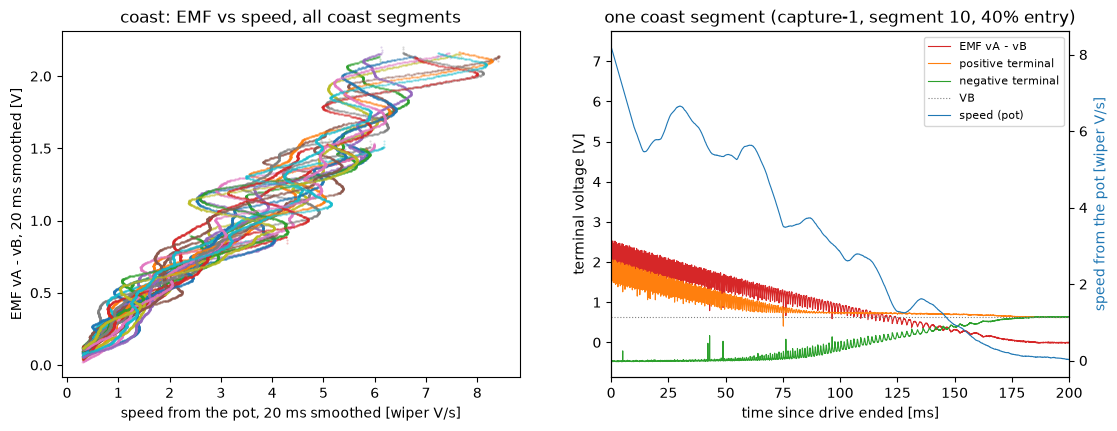

,slope_regression_s,intercept_V,slope_integral_s,segments,neg_terminal_clamp_V
mean,0.2763,0.0519,0.2875,6.0,-0.4663
min,0.2729,0.0316,0.2821,6.0,-0.4673
max,0.2826,0.0605,0.2948,6.0,-0.4649
count,5.0000,5.0000,5.0000,5.0,5.0000


In [9]:
SG_WIN = 401   # 20 ms smoothing window for speed from the pot

SKIP = 3       # samples excluded at the start of every coast segment

def coast_segments(sweeps):
    # Per coast segment: time, position (wiper V, positive along the entry
    # direction), EMF vA - vB (positive along the entry direction), the
    # positive and negative terminals and their sum, all in V.
    sp, meta = sweeps["spindown"]
    out = []
    for seg_id, seg in sp[sp["kind"] == "coast"].groupby("seg"):
        d = int(seg["dir"].iloc[0])
        vb = seg["vb"].iloc[0]
        vA, vB = term_V(seg["vmotor_a"].to_numpy(), vb), term_V(seg["vmotor_b"].to_numpy(), vb)
        out.append({
            "seg": seg_id,
            "entry_pct": int(sp.loc[sp["seg"] == seg_id - 1, "mag_pct"].iloc[0]),
            "t": np.arange(len(seg)) / TICK_HZ,
            "p": seg["pos"].to_numpy() * d * V_ADC_PER_COUNT,
            "e": (vA - vB) * d,
            "pos_t": vA if d > 0 else vB,
            "neg_t": vB if d > 0 else vA,
            "sum": vA + vB,
            "shunt_offset": seg["current_raw"].to_numpy() - seg["bias"].iloc[0],
        })
    return out

def coast_mask(c, rail):
    i = np.arange(len(c["e"]))
    return (i >= SKIP) & (c["sum"] < rail)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
pts = []
for name, sweeps in recs.items():
    for c in coast_segments(sweeps):
        v = savgol_filter(c["p"], SG_WIN, 2, deriv=1, delta=1 / TICK_HZ)
        es = savgol_filter(c["e"], SG_WIN, 2)
        i = np.arange(len(v))
        m = (i >= SG_WIN // 2) & (v > 0.3) & coast_mask(c, rails[name])
        axes[0].plot(v[m], es[m], ".", ms=1, alpha=0.3)
        pts.append(pd.DataFrame({"recording": name, "seg": c["seg"], "v": v[m], "e": es[m]}))
axes[0].set_xlabel("speed from the pot, 20 ms smoothed [wiper V/s]")
axes[0].set_ylabel("EMF vA - vB, 20 ms smoothed [V]")
axes[0].set_title("coast: EMF vs speed, all coast segments")
name, sweeps = next(iter(recs.items()))
c = coast_segments(sweeps)[2]
v = savgol_filter(c["p"], SG_WIN, 2, deriv=1, delta=1 / TICK_HZ)
axes[1].plot(c["t"] * 1e3, c["e"], lw=0.8, color="tab:red", label="EMF vA - vB")
axes[1].plot(c["t"] * 1e3, c["pos_t"], lw=0.8, color="tab:orange", label="positive terminal")
axes[1].plot(c["t"] * 1e3, c["neg_t"], lw=0.8, color="tab:green", label="negative terminal")
axes[1].axhline(vbs[name], color="grey", lw=0.8, ls=":", label="VB")
axes[1].set_xlabel("time since drive ended [ms]")
axes[1].set_ylabel("terminal voltage [V]")
ax2 = axes[1].twinx()
ax2.plot(c["t"] * 1e3, v, lw=0.8, color="tab:blue", label="speed (pot)")
ax2.set_ylabel("speed from the pot [wiper V/s]", color="tab:blue")
axes[1].set_xlim(0, 200)
axes[1].set_title(f"one coast segment ({name}, segment {c['seg']}, {c['entry_pct']}% entry)")
h1, l1 = axes[1].get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()
axes[1].legend(h1 + h2, l1 + l2, loc="upper right", fontsize=8)
plt.show()

pts = pd.concat(pts)
rows = []
ratio_rows = []
for name, g in pts.groupby("recording"):
    k = np.polyfit(g["v"], g["e"], 1)
    # Ripple-immune route: the integral of the EMF over the segment divided
    # by the travel is the slope, if E = k v.
    ratios = []
    clamp_samples = []
    for c in coast_segments(recs[name]):
        m = coast_mask(c, rails[name])
        travel = np.median(c["p"][-1000:]) - np.median(c["p"][:3])
        ratios.append(np.sum(c["e"][m]) / TICK_HZ / travel)
        ratio_rows.append({"recording": name, "entry_pct": c["entry_pct"], "ratio": ratios[-1]})
        clamp_samples.append(c["neg_t"][m & (c["e"] > 1.5)])
    rows.append({"recording": name, "slope_regression_s": k[0], "intercept_V": k[1],
                 "slope_integral_s": np.mean(ratios), "segments": len(ratios),
                 "neg_terminal_clamp_V": np.median(np.concatenate(clamp_samples))})
bemf_fit = pd.DataFrame(rows).set_index("recording")
bemf_fit.agg(["mean", "min", "max", "count"]).round(4)


The integral ratio per segment, grouped by the duty of the drive step
that set the entry speed, tests whether the slope depends on speed:


In [10]:
(pd.DataFrame(ratio_rows).groupby("entry_pct")["ratio"]
   .agg(["mean", "std", "min", "max", "count"]).round(4))


,mean,std,min,max,count
entry_pct,,,,,
20,0.2717,0.0190,0.2519,0.3091,10
30,0.2958,0.0044,0.2887,0.3051,10
40,0.2948,0.0035,0.2870,0.3004,10


Findings:

- The EMF follows the speed with a slope of 0.29 V per wiper V/s from the
  integral ratio (0.28 to 0.29 across recordings) and 0.28 from the
  regression (0.27 to 0.28), with an intercept of 0.05 V from the
  regression. By entry duty, the integral ratio is 0.30 for the 30% and
  40% entries with a standard deviation of 0.004 over the ten segments
  of each, and 0.27 with a standard deviation of 0.02 for the 20%
  entries, whose travel of about 0.16 wiper V is close to one period of
  the pot ripple below.
- The negative terminal sits at -0.47 V in every recording while the EMF
  is above about 1 V, and rises toward the bias as the EMF falls below
  that. The positive terminal reads the EMF plus the clamp level, and
  both terminals return to the bias at rest.
- The EMF decays smoothly through the segment, with a ripple of its own
  of about 10% rms at a period much shorter than the pot's. The
  pot-derived speed rides on a ripple of 20 to 30% amplitude with a
  period of roughly 0.1 to 0.2 V of wiper travel, visible in the right
  panel and as the loops in the left panel. That ripple is absent from
  the EMF, so it is on the pot side of the gear train. *Hypothesis (not
  tested here): the ripple is a periodic error of the potentiometer track
  or of the final gear stage. Notebook 06 takes it up.*
- The slope is a property of the motor and gear train as seen through
  the pot. The terminal difference removes the divider bias and the
  clamp, so neither the load of the dividers nor the clamp enters it.
  Notebook 03 compares this slope with the drive-side estimate. The
  motor-shaft constant needs the gear ratio (notebook 06).

The slope from the integral ratio is the one used below to convert EMF
volts into wiper V/s.

### 6.2 Coast deceleration vs speed

The model is Coulomb plus viscous friction,

$$\frac{dv}{dt} = -(a + b\,v), \qquad v > 0,$$

with $a$ in wiper V/s$^2$ and $b$ in 1/s. Two routes fit it. The pot
route fits the closed-form trajectory $p(t)$ of the model to the position
trace of every coast segment of a recording jointly, with one $(a, b)$
per recording and one entry speed per segment. The terminal route fits the
same model to the EMF $e(t)$ of the same segments, where $e$ stands in
for speed, and converts $a$ with the slope of section 6.1. The terminal route gives $b$ directly, since $b$ is a rate
and needs no unit conversion. The figure shows the measured speed of
every coast segment with the terminal-route model overlaid.


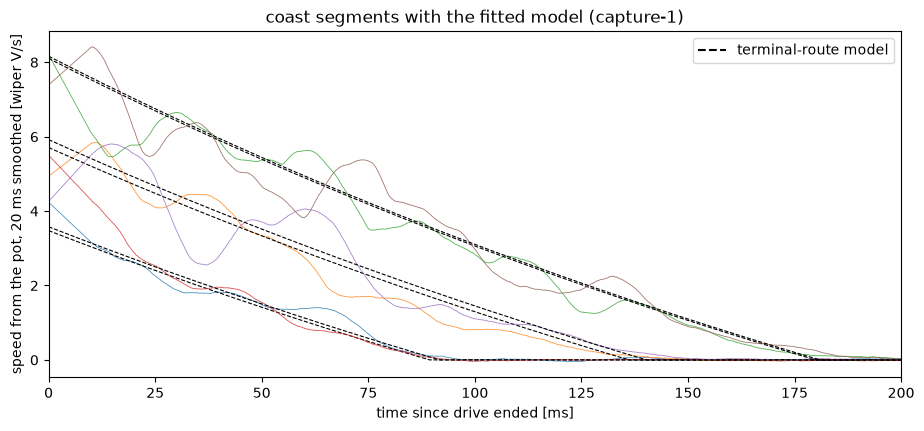

,pot route a [V/s2],pot route b [1/s],pot route rms resid [mV],terminal route a [V/s2],terminal route b [1/s],terminal route b se [1/s],terminal route rms resid [mV]
mean,39.23,1.10,4.32,34.36,3.00,0.04,65.49
min,34.61,0.00,4.15,32.86,2.79,0.04,65.23
max,44.19,2.49,4.43,37.52,3.23,0.04,65.82
count,5.00,5.00,5.00,5.00,5.00,5.00,5.00


In [11]:
FIT_N = 5000   # 250 ms of every zero-duty segment enters the fit

def traj(t, p0, v0, a, b):
    # Position under dv/dt = -(a + b v) from v0, at rest after t_stop.
    a, b = max(a, 1e-6), max(b, 1e-6)
    t_stop = np.log1p(b * v0 / a) / b
    tt = np.minimum(t, t_stop)
    return p0 + (v0 + a / b) * (1 - np.exp(-b * tt)) / b - (a / b) * tt

def speed_model(t, v0, a, b):
    a, b = max(a, 1e-6), max(b, 1e-6)
    t_stop = np.log1p(b * v0 / a) / b
    return np.where(t < t_stop, (v0 + a / b) * np.exp(-b * np.minimum(t, t_stop)) - a / b, 0.0)

def joint_fit(segs, signal, mask_fn, has_p0):
    # Shared (a, b), per-segment start value (and offset when has_p0).
    t = np.arange(FIT_N) / TICK_HZ
    per = 2 if has_p0 else 1
    def resid(x):
        r = []
        for i, c in enumerate(segs):
            y = c[signal][:FIT_N]
            m = mask_fn(c)[:FIT_N]
            if has_p0:
                model = traj(t, x[2 + per * i], x[3 + per * i], x[0], x[1])
            else:
                model = speed_model(t, x[2 + i], x[0], x[1])
            r.append((model - y)[m])
        return np.concatenate(r)
    x0 = [30.0, 5.0]
    lb = [0.0, 0.0]
    for c in segs:
        y = c[signal]
        if has_p0:
            x0 += [y[0], 5.0]
            lb += [-np.inf, 0.0]
        else:
            x0 += [max(y[3], 0.1)]
            lb += [0.0]
    res = least_squares(resid, x0, bounds=(lb, np.inf))
    dof = len(res.fun) - len(res.x)
    cov = np.linalg.inv(res.jac.T @ res.jac) * np.sum(res.fun ** 2) / dof
    se = np.sqrt(np.diag(cov))
    starts = res.x[3::2] if has_p0 else res.x[2:]
    return {"a": res.x[0], "b": res.x[1], "a_se": se[0], "b_se": se[1],
            "starts": starts, "rms_resid": np.sqrt(np.mean(res.fun ** 2))}

coast_fits = {}
for name, sweeps in recs.items():
    segs = coast_segments(sweeps)
    slope = bemf_fit.loc[name, "slope_integral_s"]
    pot = joint_fit(segs, "p", lambda c: np.ones(len(c["p"]), bool), True)
    term = joint_fit(segs, "e", lambda c: coast_mask(c, rails[name]), False)
    coast_fits[name] = {"segs": segs, "pot": pot, "term": term, "slope": slope}

fig, ax = plt.subplots(figsize=(11, 4.5))
name, f = next(iter(coast_fits.items()))
t = np.arange(FIT_N) / TICK_HZ
for i, c in enumerate(f["segs"]):
    v = savgol_filter(c["p"][:FIT_N], SG_WIN, 2, deriv=1, delta=1 / TICK_HZ)
    ax.plot(t * 1e3, v, lw=0.6, alpha=0.8)
    vm = speed_model(t, f["term"]["starts"][i], f["term"]["a"], f["term"]["b"]) / f["slope"]
    ax.plot(t * 1e3, vm, "k--", lw=0.8)
ax.plot([], [], "k--", label="terminal-route model")
ax.set_xlim(0, 200)
ax.set_xlabel("time since drive ended [ms]")
ax.set_ylabel("speed from the pot, 20 ms smoothed [wiper V/s]")
ax.set_title(f"coast segments with the fitted model ({name})")
ax.legend()
plt.show()

rows = []
for name, f in coast_fits.items():
    rows.append({
        "recording": name,
        "pot route a [V/s2]": f["pot"]["a"],
        "pot route b [1/s]": f["pot"]["b"],
        "pot route rms resid [mV]": f["pot"]["rms_resid"] * 1e3,
        "terminal route a [V/s2]": f["term"]["a"] / f["slope"],
        "terminal route b [1/s]": f["term"]["b"],
        "terminal route b se [1/s]": f["term"]["b_se"],
        "terminal route rms resid [mV]": f["term"]["rms_resid"] * 1e3,
    })
coast_tab = pd.DataFrame(rows).set_index("recording")
coast_tab.agg(["mean", "min", "max", "count"]).round(2)


Findings:

- The terminal route puts the Coulomb term at 34 wiper V/s$^2$ (33 to 38
  across recordings) and the viscous term at 3.0 1/s (2.8 to 3.2). The
  standard error on $b$ from the fit is 0.04 1/s, an optimistic figure,
  since the 65 mV rms residual is dominated by the EMF ripple, which is
  correlated from sample to sample. At the highest entry speed of about
  8 wiper V/s the viscous term contributes 24 wiper V/s$^2$, seven tenths
  of the Coulomb term, so the model curves in the figure are close to
  straight lines.
- The pot route puts the Coulomb term at 39 wiper V/s$^2$ (35 to 44) and
  drives $b$ to 1.1 1/s (0 to 2.5). The pot ripple of section 6.1 is
  larger than the curvature that separates the two terms over a single
  segment, so the pot route cannot resolve the split, and its scatter
  across recordings is twice the terminal route's for $a$ and five times
  for $b$.
- The two routes agree on the average deceleration over a segment and
  disagree on its split. Section 6.4 tests the terminal-route parameters
  against the measured stopping distances, which the pot measures without
  ripple sensitivity.

### 6.3 Brake deceleration vs speed

In brake the winding is shorted through the low-side switches. The
back-EMF drives a current through the winding resistance and the switch
on-resistance, and the resulting torque opposes the motion in proportion
to speed, so the same model applies with a much larger $b$. The terminals
are within 0.04 V of ground during brake (section 5.4), so no EMF is
readable and only the pot route is available. The
friction is the same mechanism as in coast, so the fit first holds $a$
at the terminal-route coast value of the same recording and fits $b$ and
the entry speeds, then repeats with $a$ free as a check.


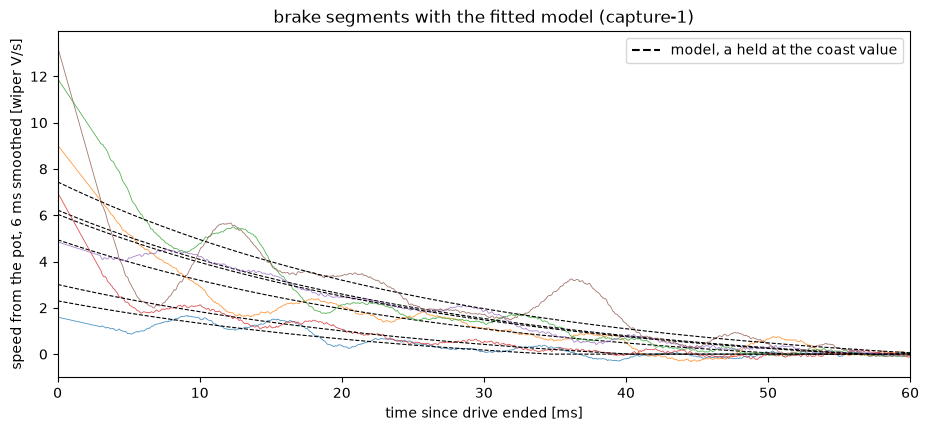

,a held [V/s2],"b, a held [1/s]",b se [1/s],"rms resid, a held [mV]",a free [V/s2],"b, a free [1/s]","rms resid, a free [mV]",brake/coast b ratio
mean,34.36,42.96,0.11,2.13,53.25,33.51,2.08,14.39
min,32.86,35.15,0.10,2.03,17.44,19.20,2.00,11.58
max,37.52,50.91,0.13,2.31,75.72,63.14,2.24,18.25
count,5.00,5.00,5.00,5.00,5.00,5.00,5.00,5.00


In [12]:
def brake_segments(sweeps):
    sp, meta = sweeps["spindown"]
    out = []
    for seg_id, seg in sp[sp["kind"] == "brake"].groupby("seg"):
        d = int(seg["dir"].iloc[0])
        vb = seg["vb"].iloc[0]
        out.append({
            "seg": seg_id,
            "entry_pct": int(sp.loc[sp["seg"] == seg_id - 1, "mag_pct"].iloc[0]),
            "t": np.arange(len(seg)) / TICK_HZ,
            "p": seg["pos"].to_numpy() * d * V_ADC_PER_COUNT,
            "vA": term_V(seg["vmotor_a"].to_numpy(), vb),
            "vB": term_V(seg["vmotor_b"].to_numpy(), vb),
        })
    return out

def brake_fit_fixed_a(segs, a_fixed):
    t = np.arange(FIT_N) / TICK_HZ
    def resid(x):
        r = []
        for i, c in enumerate(segs):
            r.append(traj(t, x[1 + 2 * i], x[2 + 2 * i], a_fixed, x[0]) - c["p"][:FIT_N])
        return np.concatenate(r)
    x0 = [40.0] + sum([[c["p"][0], 5.0] for c in segs], [])
    lb = [0.0] + sum([[-np.inf, 0.0] for _ in segs], [])
    res = least_squares(resid, x0, bounds=(lb, np.inf))
    dof = len(res.fun) - len(res.x)
    cov = np.linalg.inv(res.jac.T @ res.jac) * np.sum(res.fun ** 2) / dof
    return {"b": res.x[0], "b_se": np.sqrt(cov[0, 0]), "starts": res.x[2::2],
            "rms_resid": np.sqrt(np.mean(res.fun ** 2))}

brake_fits = {}
for name, sweeps in recs.items():
    segs = brake_segments(sweeps)
    a_coast = coast_fits[name]["term"]["a"] / coast_fits[name]["slope"]
    fixed = brake_fit_fixed_a(segs, a_coast)
    free = joint_fit(segs, "p", lambda c: np.ones(len(c["p"]), bool), True)
    brake_fits[name] = {"segs": segs, "fixed": fixed, "free": free, "a_coast": a_coast}

fig, ax = plt.subplots(figsize=(11, 4.5))
name, f = next(iter(brake_fits.items()))
t = np.arange(FIT_N) / TICK_HZ
for i, c in enumerate(f["segs"]):
    v = savgol_filter(c["p"][:FIT_N], 121, 2, deriv=1, delta=1 / TICK_HZ)
    ax.plot(t * 1e3, v, lw=0.6, alpha=0.8)
    ax.plot(t * 1e3, speed_model(t, f["fixed"]["starts"][i], f["a_coast"], f["fixed"]["b"]),
            "k--", lw=0.8)
ax.plot([], [], "k--", label="model, a held at the coast value")
ax.set_xlim(0, 60)
ax.set_xlabel("time since drive ended [ms]")
ax.set_ylabel("speed from the pot, 6 ms smoothed [wiper V/s]")
ax.set_title(f"brake segments with the fitted model ({name})")
ax.legend()
plt.show()

rows = []
for name, f in brake_fits.items():
    b_coast = coast_fits[name]["term"]["b"]
    rows.append({
        "recording": name,
        "a held [V/s2]": f["a_coast"],
        "b, a held [1/s]": f["fixed"]["b"],
        "b se [1/s]": f["fixed"]["b_se"],
        "rms resid, a held [mV]": f["fixed"]["rms_resid"] * 1e3,
        "a free [V/s2]": f["free"]["a"],
        "b, a free [1/s]": f["free"]["b"],
        "rms resid, a free [mV]": f["free"]["rms_resid"] * 1e3,
        "brake/coast b ratio": f["fixed"]["b"] / b_coast,
    })
brake_tab = pd.DataFrame(rows).set_index("recording")
brake_tab.agg(["mean", "min", "max", "count"]).round(2)


Findings:

- With $a$ held at the coast value, the brake viscous term is 43 1/s (35
  to 51 across recordings), 12 to 18 times the coast value. The winding
  short adds electrical damping of that size on top of the mechanical
  friction.
- Freeing $a$ lets the two terms trade against each other over a wide
  range ($a$ from 17 to 76 wiper V/s$^2$) with almost no change in
  residual, the same trade-off seen in the pot route of section 6.2. The
  pot ripple sets this limit, and the brake segments are too short (34 to
  62 ms) for the curvature to override it.
- The model misses the first few milliseconds of the fastest entries,
  where the measured speed drops faster than the fitted exponential. The
  ripple period at those speeds is close to the fit's time scale, so
  whether this is a real departure from the linear model is left open.

### 6.4 Stopping distance vs entry speed

For the fitted model the stopping distance from entry speed $v_0$ is

$$d(v_0) = \frac{v_0}{b} - \frac{a}{b^2}\ln\!\left(1 + \frac{b\,v_0}{a}\right).$$

The measured stopping distance of each zero-duty segment is the settled
position (median of the last 50 ms) minus the position at entry. The entry
speed comes from the fits above (the terminal route for coast, the held-a
fit for brake). The figure compares measured distances with the model
curve for both states, which is a check of the fitted parameters against
a quantity the pot measures without ripple sensitivity.


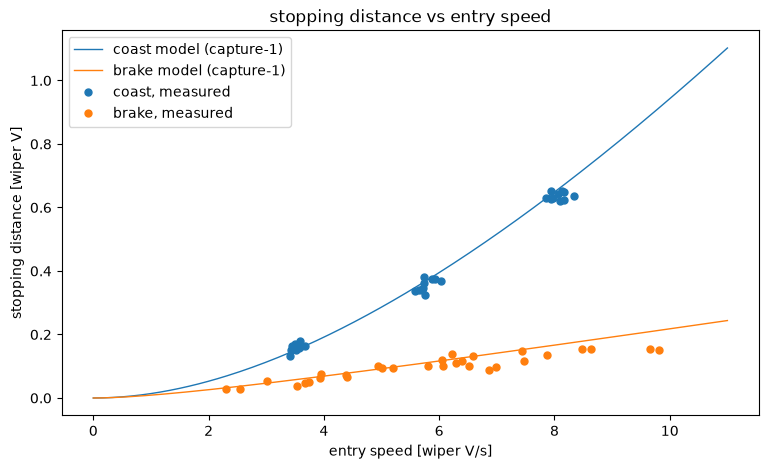

state             brake                   coast                  
entry_pct            20      30      40      20       30       40
entry_Vps  min    2.301   4.939   6.222   3.406    5.584    7.857
           max    4.396   6.994   9.817   3.680    6.028    8.338
           mean   3.547   5.974   7.857   3.520    5.772    8.067
measured_V min    0.027   0.087   0.115   0.134    0.324    0.622
           max    0.076   0.120   0.155   0.178    0.382    0.653
           mean   0.053   0.101   0.140   0.159    0.355    0.636
model_V    min    0.032   0.084   0.112   0.140    0.346    0.639
           max    0.063   0.118   0.167   0.160    0.386    0.671
           mean   0.051   0.099   0.139   0.150    0.366    0.653
error_pct  min  -19.061 -12.481 -11.609 -12.094   -2.977   -0.340
           max   20.919  16.268   9.989   8.677    6.886    6.583
           mean   0.731  -1.740  -1.350  -4.919    3.244    2.714
stop_ms    min   34.449  45.854  47.348  83.126  127.782  170.086
           max   43.298  56.454  61.626  93.641  141.268  181.715
           mean  39.087  49.818  55.484  89.397  136.103  177.789

In [13]:
def stop_dist(v0, a, b):
    return v0 / b - a / b ** 2 * np.log1p(b * v0 / a)

rows = []
for name in recs:
    cf, bf = coast_fits[name], brake_fits[name]
    for i, c in enumerate(cf["segs"]):
        v0 = cf["term"]["starts"][i] / cf["slope"]
        a, b = cf["term"]["a"] / cf["slope"], cf["term"]["b"]
        rows.append({"recording": name, "state": "coast", "entry_pct": c["entry_pct"],
                     "entry_Vps": v0,
                     "measured_V": np.median(c["p"][-1000:]) - np.median(c["p"][:3]),
                     "model_V": stop_dist(v0, a, b),
                     "stop_ms": np.log1p(b * v0 / a) / b * 1e3})
    for i, c in enumerate(bf["segs"]):
        v0 = bf["fixed"]["starts"][i]
        a, b = bf["a_coast"], bf["fixed"]["b"]
        rows.append({"recording": name, "state": "brake", "entry_pct": c["entry_pct"],
                     "entry_Vps": v0,
                     "measured_V": np.median(c["p"][-1000:]) - np.median(c["p"][:3]),
                     "model_V": stop_dist(v0, a, b),
                     "stop_ms": np.log1p(b * v0 / a) / b * 1e3})
sd = pd.DataFrame(rows)
sd["error_pct"] = (sd["model_V"] / sd["measured_V"] - 1) * 100

fig, ax = plt.subplots(figsize=(9, 5))
vv = np.linspace(0, 11, 200)
name = next(iter(recs))
cf, bf = coast_fits[name], brake_fits[name]
ax.plot(vv, stop_dist(vv, cf["term"]["a"] / cf["slope"], cf["term"]["b"]), "-",
        color="tab:blue", lw=1, label=f"coast model ({name})")
ax.plot(vv, stop_dist(vv, bf["a_coast"], bf["fixed"]["b"]), "-",
        color="tab:orange", lw=1, label=f"brake model ({name})")
for state, color in [("coast", "tab:blue"), ("brake", "tab:orange")]:
    g = sd[sd["state"] == state]
    ax.plot(g["entry_Vps"], g["measured_V"], "o", color=color, ms=5, label=f"{state}, measured")
ax.set_xlabel("entry speed [wiper V/s]")
ax.set_ylabel("stopping distance [wiper V]")
ax.set_title("stopping distance vs entry speed")
ax.legend()
plt.show()

(sd.groupby(["state", "entry_pct"])[["entry_Vps", "measured_V", "model_V", "error_pct", "stop_ms"]]
   .agg(["min", "max", "mean"]).round(3).T)


Findings:

- Coast stopping distances range from 0.13 to 0.65 wiper V for entry
  speeds of 3.4 to 8.3 wiper V/s, with stop times of 83 to 182 ms. The
  terminal-route model matches the measured distances within 7% at the
  30% and 40% entries (mean error +3%) and within about 12% at the 20%
  entries (mean -5%), where the Coulomb term dominates. The agreement across the
  speed range supports the split between the Coulomb and viscous terms
  that the pot route could not resolve. The remaining low-speed shortfall
  says the friction near rest is a little below the fitted Coulomb term,
  which notebook 04 takes up.
- Brake stopping distances are about four times shorter at the same entry
  speed, 0.03 to 0.16 wiper V, with stop times of 34 to 62 ms. The
  held-$a$ model matches them within 21%, the scatter the pot ripple
  leaves on segments this short.

## 7. Limitations and open issues

- **One unit, one supply.** All numbers describe this one servo on a
  2-cell battery that was not recharged between recordings. The gear
  train has prior wear.
- **Voltages are nominal-referenced.** All voltages scale with the true
  VDD of this unit, which was not measured (section 2). The terminal bias
  is measured per recording, 0.625 to 0.626 V against a nominal 0.623 V,
  so the absolute terminal voltages inherit only the VDD scaling. The
  nominal bias divider itself is a design value with unmeasured
  tolerance.
- **Coast from high speed is absent.** The runway between the
  repositioning end and the far endstop is too short for a coast from
  above 40% duty at this supply, so the coast model is fitted below
  8.5 wiper V/s and extrapolated above.
- **Entry speeds vary.** Each drive step starts with residual motion from
  the repositioning move, so the entry speeds are measured, never
  commanded, and the spin-down segments do not pair up.
- **The pot speed ripple.** The pot-derived speed carries a ripple of 20
  to 30% that the EMF does not show (section 6.1). Every fit that uses
  the pot alone is limited by it, in particular the split between Coulomb
  and viscous friction in section 6.2 and the whole of section 6.3.
- **The clamp and diode levels are measured levels.** The
  negative terminal's coast clamp at -0.47 V and the diode-phase levels
  (rail plus 0.93 V on one terminal, -0.58 V on the other) are read from
  this driver at these currents. They enter the validity map as state
  checks. The EMF is independent of them, since it is the terminal
  difference.
- **The fast-decay coast reading is unexplained.** Section 5.3 shows what
  the crest-scan terminals read in the 35% to 50% range and rules out
  back-EMF. The mechanism behind the reading is a hypothesis.
- **The sampling floors are this board's.** The 13.3% and 17.5% floors
  and the scan slot offsets change with board revision and firmware
  configuration.

## 8. What the next notebooks use from here

- The validity map of section 5.4, as the gate on every current and
  terminal sample by bridge state, decay mode and scan.
- The tap formula of section 2, $V_t = 3\,\text{tap} - 2 V_B$ with $V_B$
  read from the baseline of each recording, for every absolute terminal
  voltage, and the bias-free difference $v_A - v_B$ for the EMF.
- The rail, the diode level and the discriminator threshold of section
  5.3, all in corrected terminal volts, for separating the diode phase
  from the settled coast window, with the sum's rest level at $2 V_B$.
- The coast EMF $v_A - v_B$ as a direct speed signal with the slope of
  section 6.1 (0.29 V per wiper V/s), and the fact that the pot ripple
  is absent from it.
- The coast friction model of section 6.2 (Coulomb 34 wiper V/s$^2$ by
  the terminal route and 39 by the pot route, viscous 3 1/s by the
  terminal route) and the brake damping of section 6.3 (about 43 1/s),
  as inputs to the friction and inertia notebooks.
- The rule that direct back-EMF comes from coast segments, since the
  fast-decay crest scan does not deliver it in this scan geometry.
